In [1]:
import subprocess
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from tqdm import tqdm
# plt.style.use("dark_background")

In [2]:
DATASET_MODE = "pickle"
MODEL_TYPE = "cycle_gan"
INPUT_CHANNELS = 1
OUTPUT_CHANNELS = 1
GENERATOR_NETWORKS = "resnet_9blocks"
NGF = 64
NDF = 64
EPOCHS = 50
DECAY_EPOCHS = 50
BATCH_SIZE = 8

## Training

### ERA5 to Chirps

In [13]:
DATA_ROOT = "./datasets/era52chirps/"
ERA5_DATASET_PATH = "./datasets/era52chirps/trainA/era5.pkl"
CHIRPS_DATASET_PATH = "./datasets/era52chirps/trainB/chirps.pkl"
MODEL_NAME = "era52chirps"
LAMBDA_A = 40
LAMBDA_B = 40

subprocess.run(f"""
    python train.py \
    --dataroot {DATA_ROOT} \
    --dataset_mode {DATASET_MODE} \
    --pickle_file_A {ERA5_DATASET_PATH} \
    --pickle_file_B {CHIRPS_DATASET_PATH} \
    --name {MODEL_NAME} \
    --model {MODEL_TYPE} \
    --batch_size {BATCH_SIZE} \
    --ngf {NGF} \
    --ndf {NDF} \
    --input_nc {INPUT_CHANNELS} \
    --output_nc {OUTPUT_CHANNELS} \
    --netG {GENERATOR_NETWORKS} \
    --preprocess none \
    --lambda_A {LAMBDA_A} \
    --lambda_B {LAMBDA_B} \
    --norm instance \
    --netD n_layers \
    --n_layers_D 4 \
    --n_epochs {EPOCHS} \
    --n_epochs_decay {DECAY_EPOCHS} \
    --lr 0.00002 \
    --use_wandb
""", shell=True)

----------------- Options ---------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./datasets/era52chirps/       	[default: None]
             dataset_mode: pickle                        	[default: unaligned]
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 1                       

wandb: Currently logged in as: exyons007 (exyons007-iit-kanpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run roq4tjcy
wandb: Tracking run with wandb version 0.22.3
wandb: Run data is saved locally in /workspace/pytorch-CycleGAN-and-pix2pix/wandb/run-20251110_155015-roq4tjcy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run era52chirps
wandb: ⭐️ View project at https://wandb.ai/exyons007-iit-kanpur/CycleGAN-and-pix2pix
wandb: 🚀 View run at https://wandb.ai/exyons007-iit-kanpur/CycleGAN-and-pix2pix/runs/roq4tjcy


create web directory checkpoints/era52chirps/web...


/workspace/pytorch-CycleGAN-and-pix2pix/models/base_model.py:182: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  errors_ret[name] = float(getattr(self, "loss_" + name))  # float(...) works for both scalar tensor and float number


[Rank 0] (epoch: 1, iters: 100, time: 0.053, data: 0.048) , D_A: 0.818, G_A: 0.658, cycle_A: 4.046, idt_A: 3.015, D_B: 0.210, G_B: 1.039, cycle_B: 5.839, idt_B: 1.980

[Rank 0] (epoch: 1, iters: 200, time: 0.055, data: 0.001) , D_A: 0.697, G_A: 1.154, cycle_A: 7.429, idt_A: 2.855, D_B: 0.186, G_B: 0.496, cycle_B: 5.851, idt_B: 3.719

[Rank 0] (epoch: 1, iters: 300, time: 0.054, data: 0.001) , D_A: 0.395, G_A: 0.467, cycle_A: 6.406, idt_A: 3.423, D_B: 0.357, G_B: 0.799, cycle_B: 7.430, idt_B: 3.122

[Rank 0] (epoch: 1, iters: 400, time: 1.103, data: 0.001) , D_A: 0.569, G_A: 0.693, cycle_A: 1.826, idt_A: 1.994, D_B: 0.414, G_B: 0.199, cycle_B: 4.016, idt_B: 0.871

[Rank 0] (epoch: 1, iters: 500, time: 0.057, data: 0.001) , D_A: 0.608, G_A: 2.201, cycle_A: 1.956, idt_A: 3.411, D_B: 0.089, G_B: 1.266, cycle_B: 6.948, idt_B: 0.941

learning rate 0.0000200 -> 0.0000200
End of epoch 1 / 100 	 Time Taken: 23 sec
[Rank 0] (epoch: 2, iters: 81, time: 0.056, data: 0.001) , D_A: 0.303, G_A: 0.616

Traceback (most recent call last):
  File "/workspace/pytorch-CycleGAN-and-pix2pix/train.py", line 58, in <module>
    model.optimize_parameters()  # calculate loss functions, get gradients, update network weights
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspace/pytorch-CycleGAN-and-pix2pix/models/cycle_gan_model.py", line 185, in optimize_parameters
    self.forward()  # compute fake images and reconstruction images.
    ^^^^^^^^^^^^^^
  File "/workspace/pytorch-CycleGAN-and-pix2pix/models/cycle_gan_model.py", line 119, in forward
    self.rec_B = self.netG_A(self.fake_A)  # G_A(G_B(B))
                 ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspace/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
socket.send() raised exception.
socket.send() raised exception.
  File "/workspace/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1784,

KeyboardInterrupt: 

socket.send() raised exception.
socket.send() raised exception.
await self._send_server_request(request)socket.send() raised exception.
socket.send() raised exception.

  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/service/service_client.py", line 64, in _send_server_request
    await self._writer.drain()
  File "/usr/lib/python3.12/asyncio/streams.py", line 380, in drain
    raise exc
  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/asyncio_manager.py", line 181, in fn_wrap_exceptions
    await fn()
  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/service/service_client.py", line 38, in publish
socket.send() raised exception.
    await self._send_server_request(request)
  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/service/service_client.py", line 64, in _send_server_request
socket.send() raised exception.
    await self._writer.drain()
  File "/usr/lib/python3.12/asyncio/streams.py", line 380, in drain



socket.send() raised exception.
socket.send() raised exception.
  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/service/service_client.py", line 64, in _send_server_request
    socket.send() raised exception.
socket.send() raised exception.
await self._writer.drain()
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
  File "/usr/lib/python3.12/asyncio/streams.py", line 380, in drain
socket.send() raised exception.
    raise exc
  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/asyncio_manager.py", line 181, in fn_wrap_exceptions
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
    await fn()socket.send() raised exception.

  File "/workspace/.venv/lib/python3.12/site-packages/wandb/sdk/lib/service/service_client.py", line 38, in p

### CHIRPS upscaled to CHIRPS

In [29]:
CHIRPS_UPSCALED_DATASET_PATH = "./datasets/chirps_upscaled_2_chirps/trainA/chirps_reprojected.pkl"
CHIRPS_DATASET_PATH = "./datasets/chirps_upscaled_2_chirps/trainB/chirps.pkl"
MODEL_NAME = "chirps_upscaled_2_chirps"
DATA_ROOT = "./datasets/chirps_upscaled_2_chirps"
LAMBDA_A = 10
LAMBDA_B = 10

subprocess.run(f"""
    python train.py \
    --dataroot {DATA_ROOT} \
    --dataset_mode {DATASET_MODE} \
    --pickle_file_A {CHIRPS_UPSCALED_DATASET_PATH} \
    --pickle_file_B {CHIRPS_DATASET_PATH} \
    --name {MODEL_NAME} \
    --model {MODEL_TYPE} \
    --batch_size {BATCH_SIZE} \
    --ngf {NGF} \
    --ndf {NDF} \
    --input_nc {INPUT_CHANNELS} \
    --output_nc {OUTPUT_CHANNELS} \
    --netG {GENERATOR_NETWORKS} \
    --preprocess none \
    --lambda_A {LAMBDA_A} \
    --lambda_B {LAMBDA_B} \
    --norm instance \
    --netD n_layers \
    --n_layers_D 4 \
    --n_epochs {EPOCHS} \
    --n_epochs_decay {DECAY_EPOCHS} \
    # --use_wandb
""", shell=True)

----------------- Options ---------------
               batch_size: 8                             	[default: 1]
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
                crop_size: 256                           
                 dataroot: ./datasets/chirps_upscaled_2_chirps	[default: None]
             dataset_mode: pickle                        	[default: unaligned]
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 1                             
                 gan_mode: lsgan                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 1     

/workspace/pytorch-CycleGAN-and-pix2pix/models/base_model.py:182: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  errors_ret[name] = float(getattr(self, "loss_" + name))  # float(...) works for both scalar tensor and float number


[Rank 0] (epoch: 1, iters: 200, time: 0.018, data: 0.085) , D_A: nan, G_A: nan, cycle_A: nan, idt_A: nan, D_B: nan, G_B: nan, cycle_B: nan, idt_B: nan



/workspace/pytorch-CycleGAN-and-pix2pix/util/util.py:34: RuntimeWarning: invalid value encountered in cast
  return image_numpy.astype(imtype)


[Rank 0] (epoch: 1, iters: 400, time: 0.019, data: 0.001) , D_A: nan, G_A: nan, cycle_A: nan, idt_A: nan, D_B: nan, G_B: nan, cycle_B: nan, idt_B: nan

[Rank 0] (epoch: 1, iters: 600, time: 0.018, data: 0.001) , D_A: nan, G_A: nan, cycle_A: nan, idt_A: nan, D_B: nan, G_B: nan, cycle_B: nan, idt_B: nan

learning rate 0.0002000 -> 0.0002000
End of epoch 1 / 100 	 Time Taken: 11 sec


Traceback (most recent call last):
  File "/workspace/pytorch-CycleGAN-and-pix2pix/train.py", line 58, in <module>
    model.optimize_parameters()  # calculate loss functions, get gradients, update network weights
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspace/pytorch-CycleGAN-and-pix2pix/models/cycle_gan_model.py", line 189, in optimize_parameters
    self.backward_G()  # calculate gradients for G_A and G_B
    ^^^^^^^^^^^^^^^^^
  File "/workspace/pytorch-CycleGAN-and-pix2pix/models/cycle_gan_model.py", line 180, in backward_G
    self.loss_G.backward()
  File "/workspace/.venv/lib/python3.12/site-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/workspace/.venv/lib/python3.12/site-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/workspace/.venv/lib/python3.12/site-packages/torch/autograd/graph.py", line 829, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into 

KeyboardInterrupt: 

## Testing

### ERA5 to CHIRPS

In [20]:
DATA_ROOT = "./datasets/era52chirps/"
ERA5_DATASET_PATH = "./datasets/era52chirps/trainA/era5.pkl"
CHIRPS_DATASET_PATH = "./datasets/era52chirps/trainB/chirps.pkl"
MODEL_NAME = "era52chirps"
NUM_TEST = 10

subprocess.run(f"""
    python test.py \
    --eval \
    --dataroot {DATA_ROOT} \
    --dataset_mode {DATASET_MODE} \
    --pickle_file_A {ERA5_DATASET_PATH} \
    --pickle_file_B {CHIRPS_DATASET_PATH} \
    --name {MODEL_NAME} \
    --model {MODEL_TYPE} \
    --ngf {NGF} \
    --ndf {NDF} \
    --input_nc {INPUT_CHANNELS} \
    --output_nc {OUTPUT_CHANNELS} \
    --netG {GENERATOR_NETWORKS} \
    --num_test {NUM_TEST} \
    --preprocess none \
    --verbose \
    --no_dropout \
    --epoch latest
""", shell=True)

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/era52chirps/       	[default: None]
             dataset_mode: pickle                        	[default: unaligned]
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: True                          	[default: False]
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 1                             	[default: 3]
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[defa

CompletedProcess(args='\n    python test.py     --eval     --dataroot ./datasets/era52chirps/     --dataset_mode pickle     --pickle_file_A ./datasets/era52chirps/trainA/era5.pkl     --pickle_file_B ./datasets/era52chirps/trainB/chirps.pkl     --name era52chirps     --model cycle_gan     --ngf 64     --ndf 64     --input_nc 1     --output_nc 1     --netG resnet_9blocks     --num_test 10     --preprocess none     --verbose     --no_dropout     --epoch latest\n', returncode=0)

### CHIRPS Upscaled to CHIRPS

In [4]:
CHIRPS_UPSCALED_DATASET_PATH = "./datasets/chirps_upscaled_2_chirps/trainA/chirps_reprojected.pkl"
CHIRPS_DATASET_PATH = "./datasets/chirps_upscaled_2_chirps/trainB/chirps.pkl"
MODEL_NAME = "chirps_upscaled_2_chirps"
DATA_ROOT = "./datasets/chirps_upscaled_2_chirps"
NUM_TEST = 100

subprocess.run(f"""
    python test.py \
    --eval \
    --dataroot {DATA_ROOT} \
    --dataset_mode {DATASET_MODE} \
    --pickle_file_A {CHIRPS_UPSCALED_DATASET_PATH} \
    --pickle_file_B {CHIRPS_DATASET_PATH} \
    --name {MODEL_NAME} \
    --model {MODEL_TYPE} \
    --ngf {NGF} \
    --ndf {NDF} \
    --input_nc {INPUT_CHANNELS} \
    --output_nc {OUTPUT_CHANNELS} \
    --netG {GENERATOR_NETWORKS} \
    --num_test {NUM_TEST} \
    --preprocess none \
    --verbose \
    --no_dropout \
    --epoch latest
""", shell=True)

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/chirps_upscaled_2_chirps	[default: None]
             dataset_mode: pickle                        	[default: unaligned]
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: True                          	[default: False]
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 1                             	[default: 3]
                  isTrain: False                         	[default: None]
                load_iter: 0                             	

CompletedProcess(args='\n    python test.py     --eval     --dataroot ./datasets/chirps_upscaled_2_chirps     --dataset_mode pickle     --pickle_file_A ./datasets/chirps_upscaled_2_chirps/trainA/chirps_reprojected.pkl     --pickle_file_B ./datasets/chirps_upscaled_2_chirps/trainB/chirps.pkl     --name chirps_upscaled_2_chirps     --model cycle_gan     --ngf 64     --ndf 64     --input_nc 1     --output_nc 1     --netG resnet_9blocks     --num_test 100     --preprocess none     --verbose     --no_dropout     --epoch latest\n', returncode=0)

## Plot results

### ERA5 to CHIRPS

In [ ]:
for n in range(NUM_TEST):
    # pred_chirps = Image.open(f"./checkpoints/era52chirps/web/images/epoch{N}_fake_A.png")
    # true_chirps = Image.open(f"./checkpoints/era52chirps/web/images/epoch{N}_real_B.png")
    # true_era5 = Image.open(f"./checkpoints/era52chirps/web/images/epoch{N}_real_A.png")

    pred_chirps = Image.open(f"./results/era52chirps/test_latest/images/{n}_fake_B.png")
    true_chirps = Image.open(f"./results/era52chirps/test_latest/images/{n}_real_B.png")
    true_era5 = Image.open(f"./results/era52chirps/test_latest/images/{n}_real_A.png")

    pred_chirps = np.array(pred_chirps.convert("L"))
    pred_chirps[pred_chirps < 0.1] = 0.0
    true_chirps = np.array(true_chirps.convert("L"))
    true_era5 = np.array(true_era5.convert("L"))

    fig, axs = plt.subplots(1, 3, figsize=(12, 7))

    fig_1 = axs[0].imshow(true_era5, cmap="turbo")
    axs[0].set_title("Input ERA5")
    axs[0].axis("off");
    divider = make_axes_locatable(axs[0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(fig_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

    fig_2 = axs[1].imshow(pred_chirps, cmap="turbo")
    axs[1].set_title("Downscaled ERA5")
    axs[1].axis("off");
    divider = make_axes_locatable(axs[1])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(fig_2, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

    fig_3 = axs[2].imshow(true_chirps, cmap="turbo")
    axs[2].set_title("CHIRPS")
    axs[2].axis("off");
    divider = make_axes_locatable(axs[2])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(fig_3, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

    plt.suptitle(f"N={n}", x=0.5, y=0.8)
    plt.tight_layout()

### CHIRPS Downscaled to CHIRPS

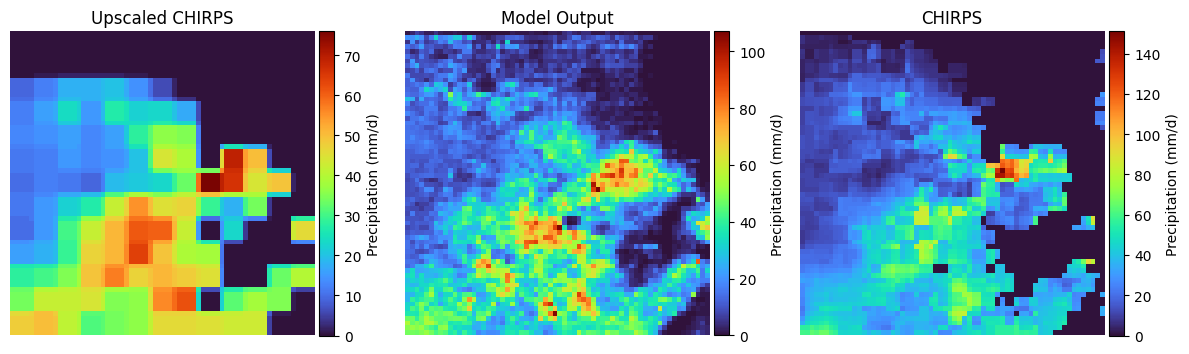

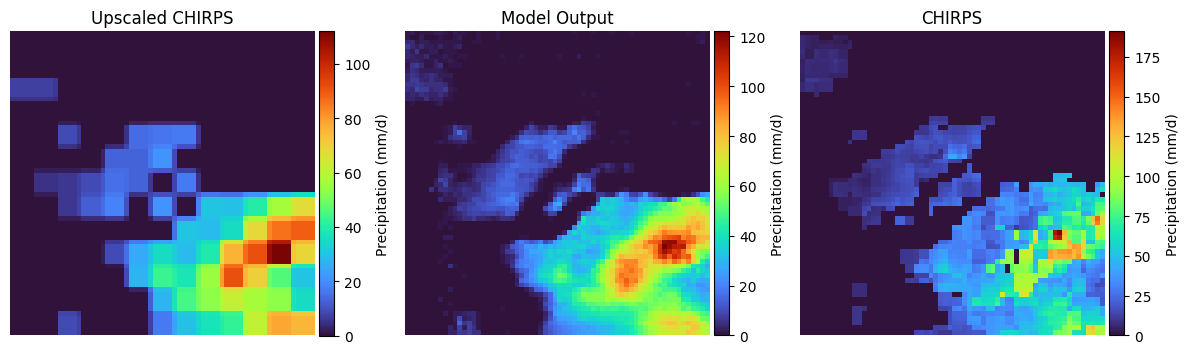

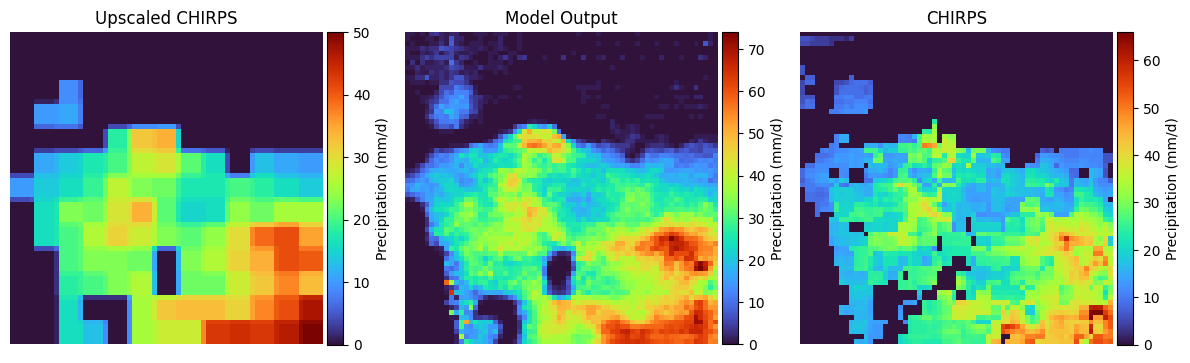

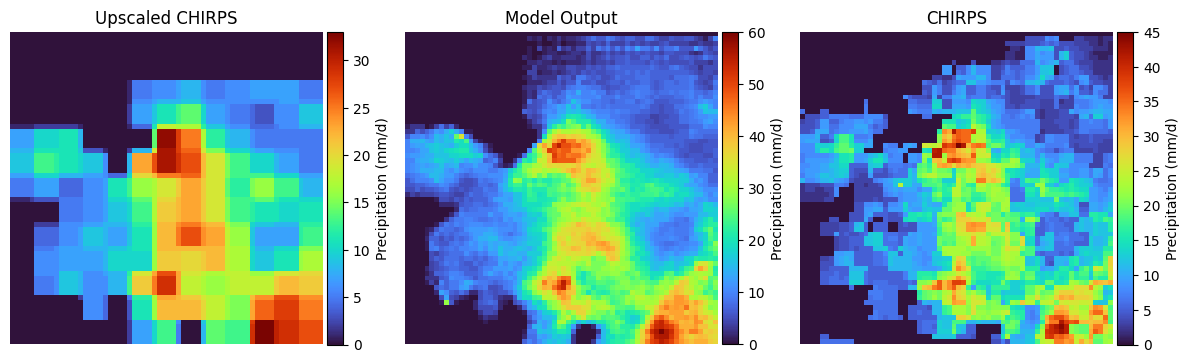

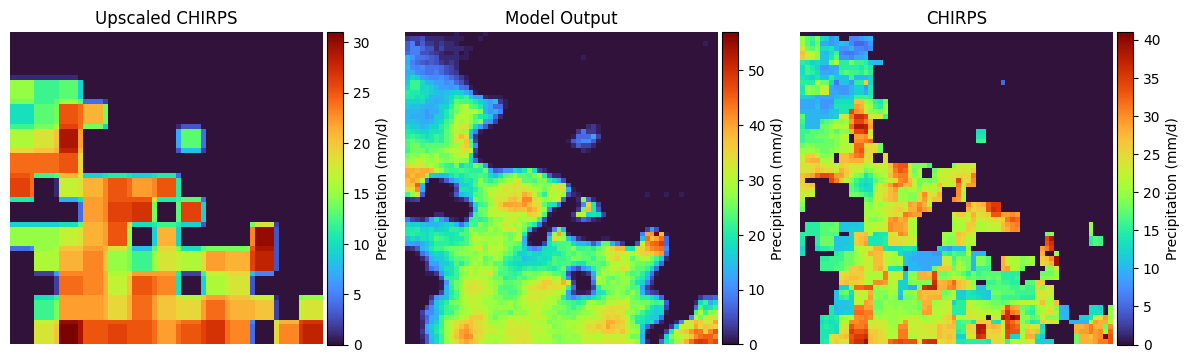

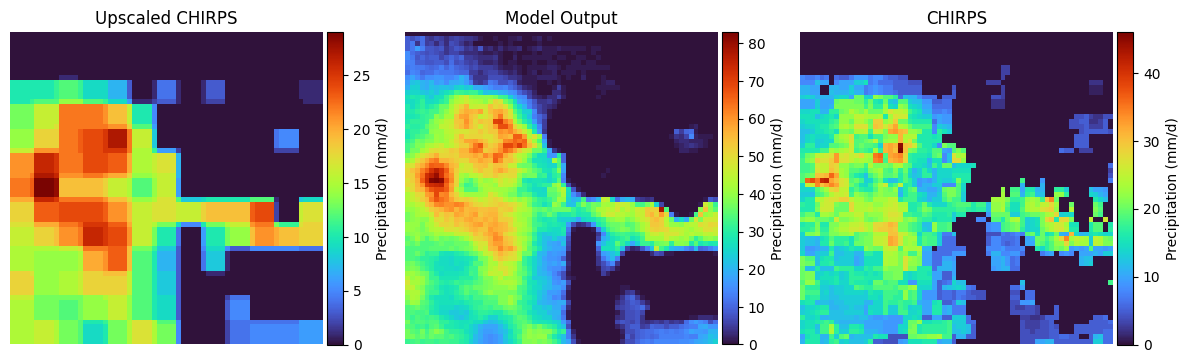

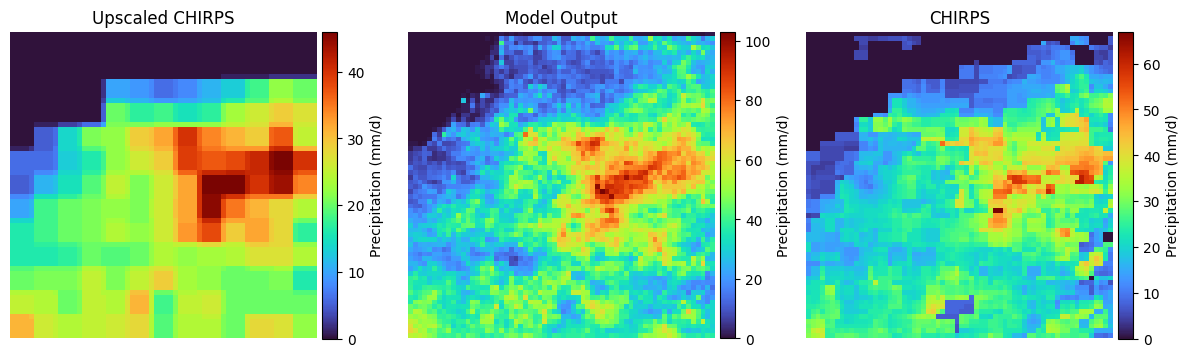

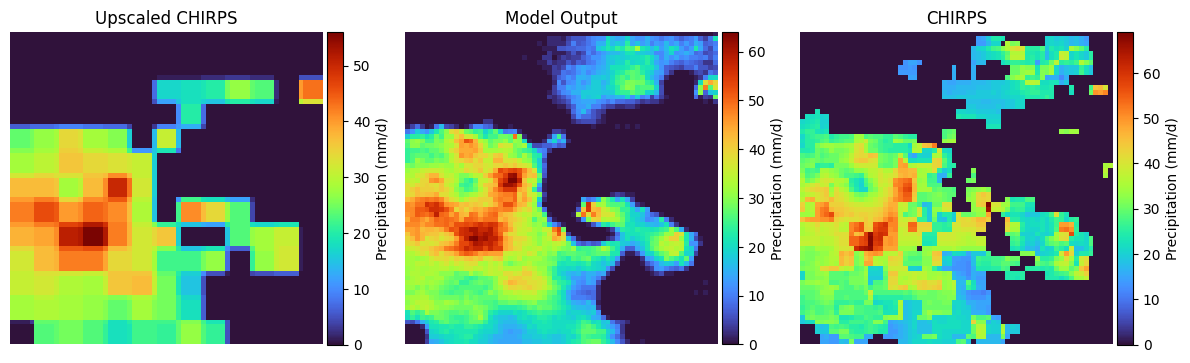

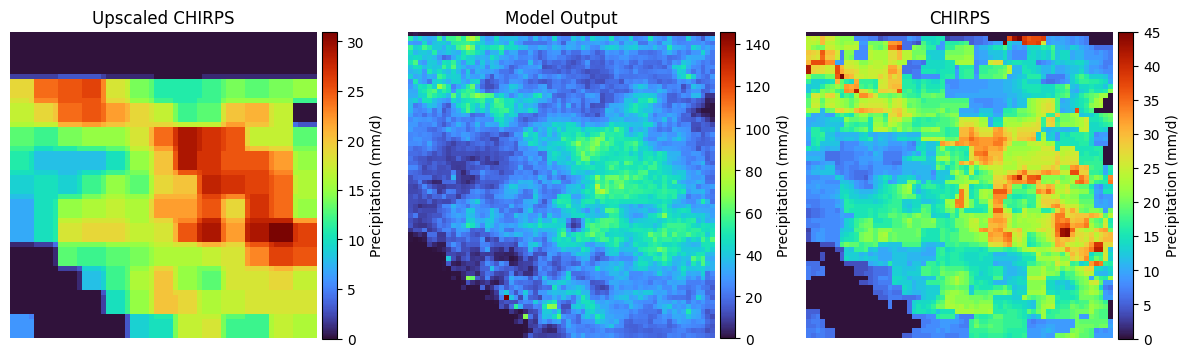

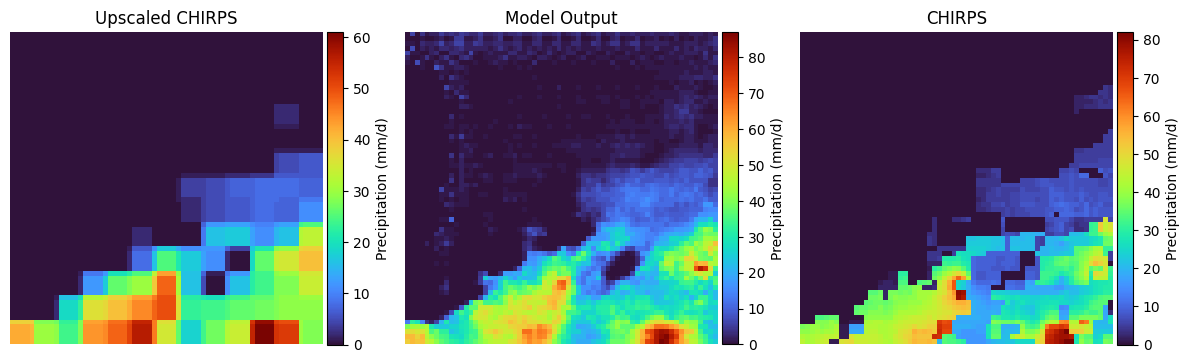

In [4]:
for n in range(10):
    # pred_chirps = Image.open(f"./checkpoints/chirps_upscaled_2_chirps/web/images/epoch{N}_fake_A.png")
    # true_chirps = Image.open(f"./checkpoints/chirps_upscaled_2_chirps/web/images/epoch{N}_real_B.png")
    # true_era5 = Image.open(f"./checkpoints/chirps_upscaled_2_chirps/web/images/epoch{N}_real_A.png")

    pred_chirps = Image.open(f"./results/chirps_upscaled_2_chirps/test_latest/images/{n}_fake_B.png")
    true_chirps = Image.open(f"./results/chirps_upscaled_2_chirps/test_latest/images/{n}_real_B.png")
    true_era5 = Image.open(f"./results/chirps_upscaled_2_chirps/test_latest/images/{n}_real_A.png")

    pred_chirps = np.array(pred_chirps.convert("L"))
    # pred_chirps[pred_chirps < 0.1] = 0.0
    true_chirps = np.array(true_chirps.convert("L"))
    true_era5 = np.array(true_era5.convert("L"))

    fig, axs = plt.subplots(1, 3, figsize=(12, 7))

    fig_1 = axs[0].imshow(true_era5, cmap="turbo")
    axs[0].set_title("Upscaled CHIRPS")
    axs[0].axis("off");
    divider = make_axes_locatable(axs[0])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(fig_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

    fig_2 = axs[1].imshow(pred_chirps, cmap="turbo")
    axs[1].set_title("Model Output")
    axs[1].axis("off");
    divider = make_axes_locatable(axs[1])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(fig_2, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

    fig_3 = axs[2].imshow(true_chirps, cmap="turbo")
    axs[2].set_title("CHIRPS")
    axs[2].axis("off");
    divider = make_axes_locatable(axs[2])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(fig_3, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

    # plt.suptitle(f"N={n}", x=0.5, y=0.8)
    plt.tight_layout()

In [5]:
pred_images = []
real_images = []
for n in tqdm(range(NUM_TEST)):
    pred_chirps = Image.open(f"./results/chirps_upscaled_2_chirps/test_latest/images/{n}_fake_B.png")
    true_chirps = Image.open(f"./results/chirps_upscaled_2_chirps/test_latest/images/{n}_real_B.png")

    pred_chirps = np.array(pred_chirps.convert("L"))
    true_chirps = np.array(true_chirps.convert("L"))

    pred_images.append(pred_chirps)
    real_images.append(true_chirps)
pred_images = np.array(pred_images)
real_images = np.array(real_images)

100%|██████████| 100/100 [00:00<00:00, 4502.02it/s]


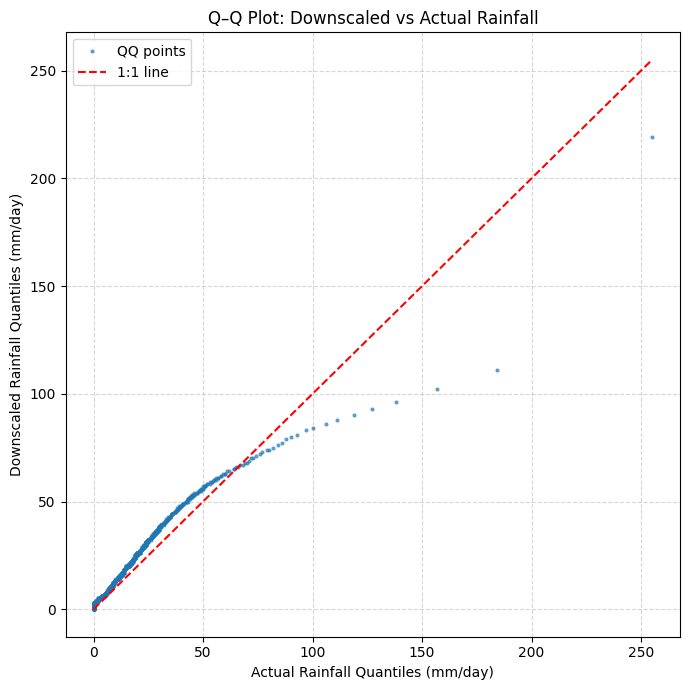

Mean Bias: 56.353
RMSE: 6.667


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_bias_using_QQ_plot(pred_images, true_images):
    # Flatten all pixels across all days (excluding NaNs or negatives if any)
    downscaled_flat = pred_images.flatten()
    actual_flat = true_images.flatten()

    # Optionally, remove missing or invalid rainfall values (e.g., negative or NaN)
    mask = np.isfinite(actual_flat) & np.isfinite(downscaled_flat)
    downscaled_flat = downscaled_flat[mask]
    actual_flat = actual_flat[mask]

    # (Optional) Remove zero rainfall values if you only want to focus on rainy days
    # nonzero_mask = (actual_flat > 0) & (downscaled_flat > 0)
    # downscaled_flat = downscaled_flat[nonzero_mask]
    # actual_flat = actual_flat[nonzero_mask]

    # --- Q-Q Plot ---
    plt.figure(figsize=(6, 6))
    stats.probplot(downscaled_flat, dist="norm", plot=plt)  # sanity check (normal)
    plt.close()

    # Use Q-Q plot comparing two datasets directly
    quantiles = np.linspace(0, 100, 1000)
    q_actual = np.percentile(actual_flat, quantiles)
    q_downscaled = np.percentile(downscaled_flat, quantiles)

    plt.figure(figsize=(7, 7))
    plt.plot(q_actual, q_downscaled, 'o', markersize=2, alpha=0.6, label='QQ points')
    plt.plot([0, max(q_actual.max(), q_downscaled.max())],
            [0, max(q_actual.max(), q_downscaled.max())],
            'r--', label='1:1 line')

    plt.xlabel('Actual Rainfall Quantiles (mm/day)')
    plt.ylabel('Downscaled Rainfall Quantiles (mm/day)')
    plt.title('Q–Q Plot: Downscaled vs Actual Rainfall')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- Bias interpretation ---
    # You can also compute mean bias, RMSE, etc. for reference:
    mean_bias = np.mean(downscaled_flat - actual_flat)
    rmse = np.sqrt(np.mean((downscaled_flat - actual_flat)**2))
    print(f"Mean Bias: {mean_bias:.3f}")
    print(f"RMSE: {rmse:.3f}")
    
plot_bias_using_QQ_plot(pred_images, real_images)

## Plot Losses

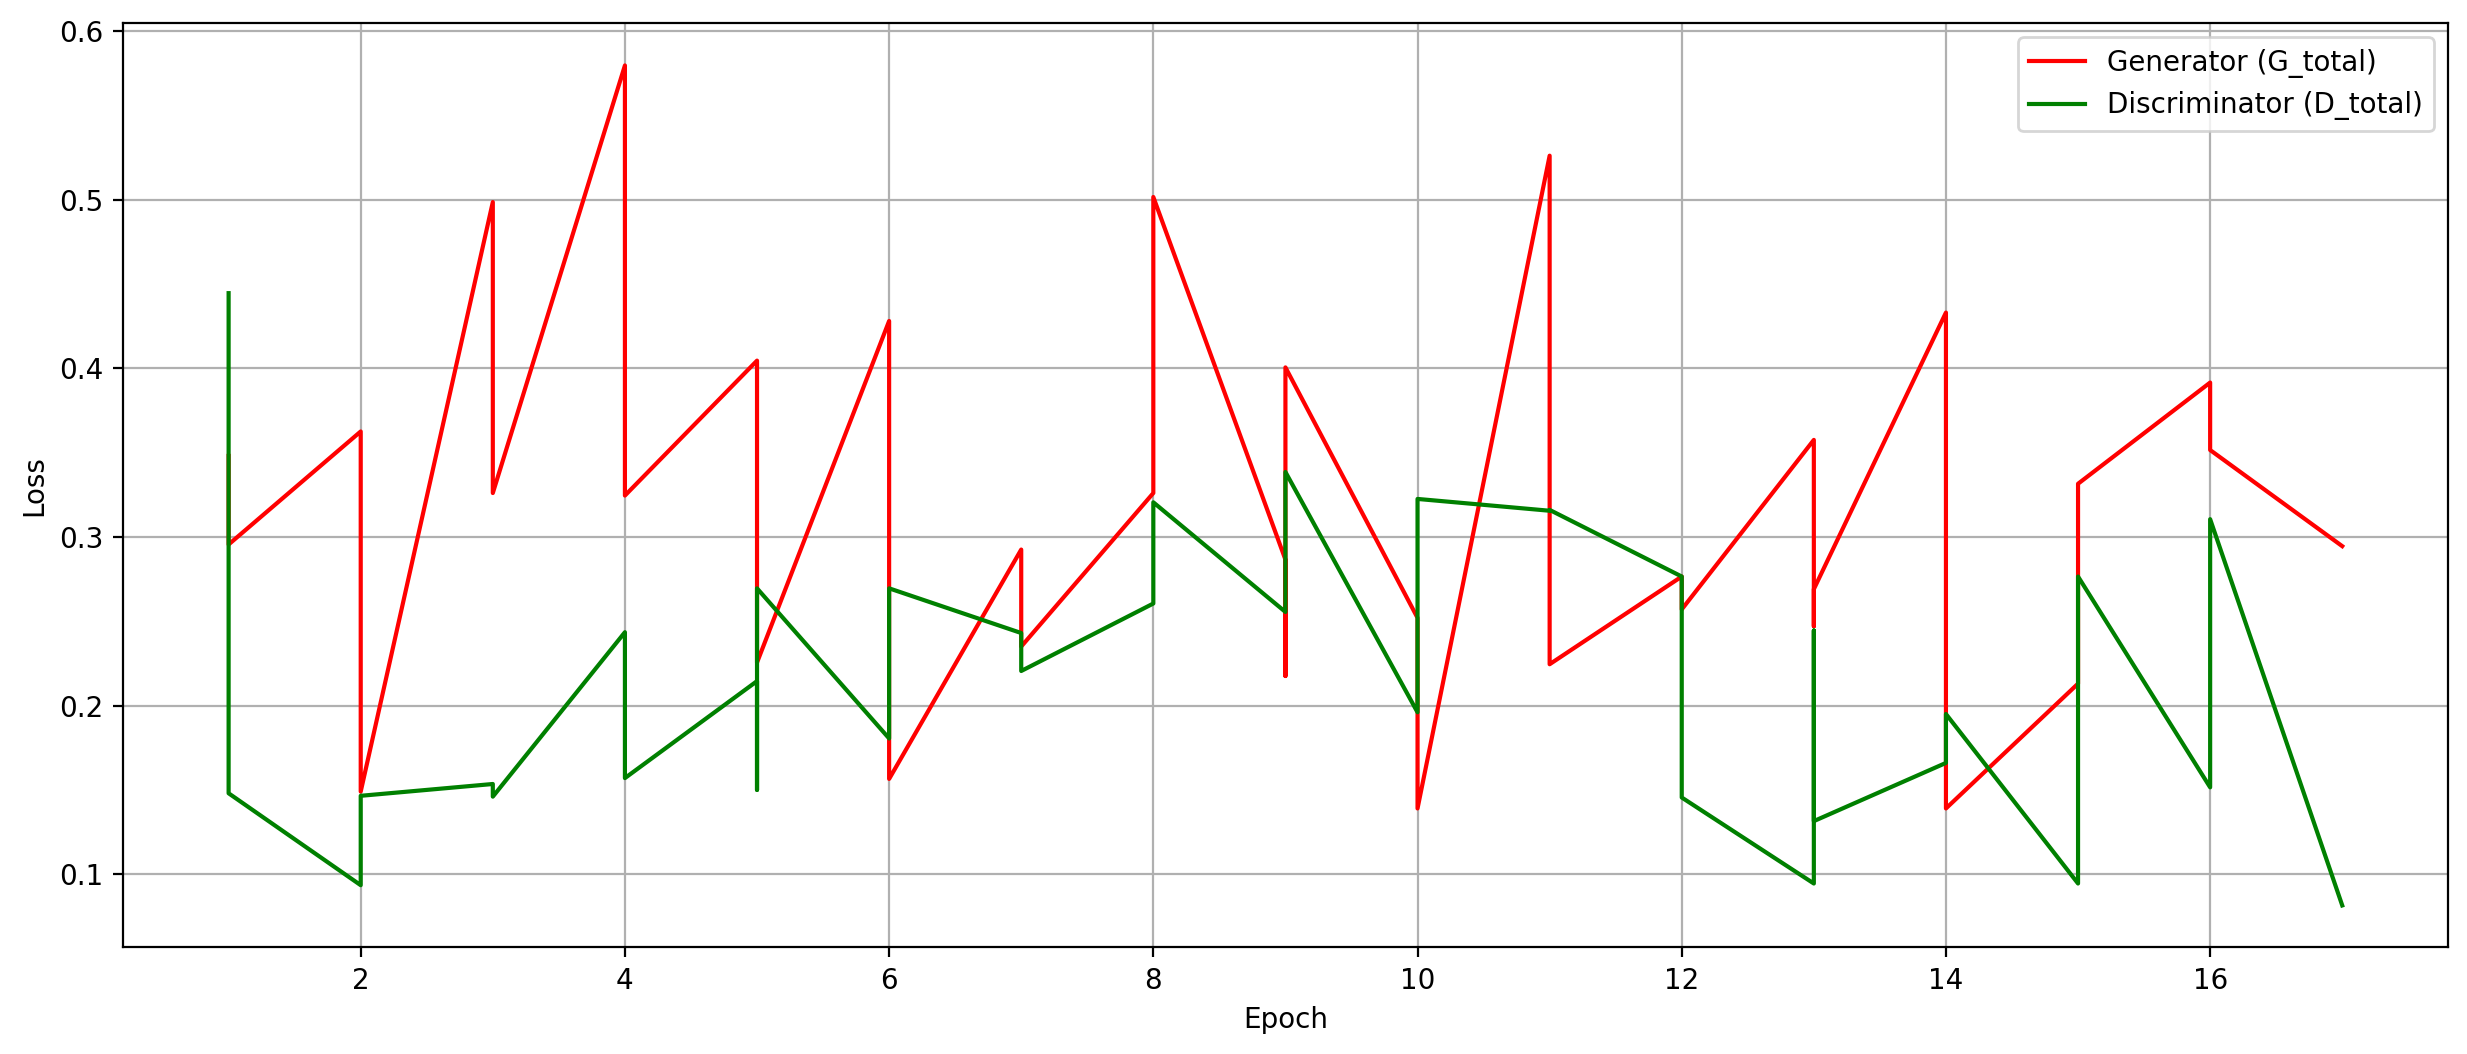

In [ ]:
import re
import matplotlib.pyplot as plt

def plot_gen_disc_losses(log_path, line_interval=10, nb_data=10800, enforce_last_line=True):
    # Read lines
    with open(log_path, 'r') as f:
        lines = f.readlines()

    # Select lines at intervals + possibly the last line
    lines_for_plot = []
    for i in range(1, len(lines)):
        if (i-1) % line_interval == 0:
            lines_for_plot.append(lines[i])
    if enforce_last_line and lines:
        lines_for_plot.append(lines[-1])

    # Prepare dict for stats
    stats = {"epoch": [], "G_total": [], "D_total": []}

    # Regex for epoch+iters
    pattern = r"epoch:\s*([0-9]+),\s*iters:\s*([0-9]+)"
    for l in lines_for_plot:
        if "epoch:" not in l:
            continue
        search = re.search(pattern, l)
        if not search:
            continue
        epoch = int(search.group(1))
        iters = int(search.group(2))
        stats["epoch"].append(epoch)

        # After the part “) , “ parse all metric pairs
        if ") ," in l:
            metrics_str = l.split(") ,",1)[1]
        else:
            # skip if format differs
            continue
        pairs = [p.strip() for p in metrics_str.split(',')]
        # initialize local accumulators
        g_sum = 0.0
        d_sum = 0.0
        count_g = 0
        count_d = 0

        for pair in pairs:
            if ':' not in pair:
                continue
            key, val = pair.split(':',1)
            key = key.strip()
            try:
                v = float(val.strip())
            except ValueError:
                continue

            if key.startswith("G_"):   # generator losses
                g_sum += v
                count_g += 1
            elif key.startswith("D_"): # discriminator losses
                d_sum += v
                count_d += 1
            # else: ignore cycle_, idt_, etc

        # compute average if you like (or just sum)
        stats["G_total"].append(g_sum / count_g if count_g>0 else None)
        stats["D_total"].append(d_sum / count_d if count_d>0 else None)

    # Plot
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(stats["epoch"], stats["G_total"], "r", label="Generator (G_total)")
    plt.plot(stats["epoch"], stats["D_total"], "g", label="Discriminator (D_total)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    # plt.title("Generator & Discriminator Losses over Training")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_gen_disc_losses("./checkpoints/chirps_upscaled_2_chirps/loss_log.txt", nb_data=300)